# Bài tập 2 – Tiền xử lý và khai phá dữ liệu Online Retail

**Nguồn:** UCI Machine Learning Repository – Online Retail  
**Bài toán:** biến dữ liệu giao dịch thô thành thông tin có thể hỗ trợ quyết định kinh doanh.

Notebook trả lời 7 câu hỏi:

1. Dữ liệu đang có vấn đề gì?
2. Vấn đề nào cần giải quyết và vấn đề nào phải giữ lại để phân tích?
3. Làm sạch dữ liệu ra sao?
4. Đã thực hiện những phân tích nào?
5. Vì sao chọn RFM, K-Means và luật kết hợp?
6. Kết quả trước và sau tiền xử lý khác nhau thế nào?
7. Kết quả mong muốn và giới hạn của bài là gì?

> Dữ liệu gồm các giao dịch của một nhà bán lẻ trực tuyến tại Anh từ 01/12/2010 đến 09/12/2011.


## 1. Chuẩn bị môi trường

Các thư viện chính:

- `pandas`, `numpy`: đọc và xử lý dữ liệu;
- `matplotlib`: trực quan hóa;
- `scikit-learn`: chuẩn hóa, K-Means và đánh giá mô hình;
- `Counter`, `combinations`: tự xây dựng luật kết hợp theo cặp, không phụ thuộc `mlxtend`.


In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

# Tự tìm file khi notebook nằm cạnh file Excel hoặc trong thư mục output/notebooks.
candidates = [
    Path("Online Retail.xlsx"),
    Path("upload/Online Retail.xlsx"),
    Path("../../upload/Online Retail.xlsx"),
    Path("../upload/Online Retail.xlsx"),
]
DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy Online Retail.xlsx. Hãy đặt file cạnh notebook "
        "hoặc sửa biến DATA_PATH."
    )
print("Đọc dữ liệu từ:", DATA_PATH.resolve())


Đọc dữ liệu từ: D:\Study\Khaiphadulieu\Online Retail v2\Online Retail.xlsx


## 2. Đọc và hiểu dữ liệu thô

Mỗi dòng là một mặt hàng trong một hóa đơn. Một hóa đơn có thể có nhiều dòng.

| Thuộc tính | Ý nghĩa |
|---|---|
| `InvoiceNo` | Mã hóa đơn; bắt đầu bằng `C` là hóa đơn hủy |
| `StockCode` | Mã sản phẩm |
| `Description` | Tên sản phẩm |
| `Quantity` | Số lượng; âm thường biểu thị hoàn trả/hủy |
| `InvoiceDate` | Thời điểm giao dịch |
| `UnitPrice` | Đơn giá bảng Anh |
| `CustomerID` | Mã khách hàng |
| `Country` | Quốc gia của khách hàng |


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Online Retail")
print(f"Kích thước: {df.shape[0]:,} dòng × {df.shape[1]} cột")
display(df.head())
display(df.dtypes.rename("Kiểu dữ liệu").to_frame())


Kích thước: 541,909 dòng × 8 cột


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom


,Kiểu dữ liệu
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[us]
UnitPrice,float64
CustomerID,float64
Country,str


## 3. Dữ liệu có vấn đề gì?

Cần kiểm tra đồng thời:

- giá trị thiếu (`CustomerID`, `Description`);
- dòng trùng hoàn toàn;
- hóa đơn hủy (`InvoiceNo` bắt đầu bằng `C`);
- số lượng âm và giá không dương;
- dữ liệu không phải sản phẩm thật như phí bưu điện/phí ngân hàng;
- tháng 12/2011 chỉ có dữ liệu đến ngày 09/12 nên không được so sánh như một tháng đầy đủ.


In [3]:
invoice_text = df["InvoiceNo"].astype(str)
cancelled = invoice_text.str.upper().str.startswith("C")

quality_before = pd.Series({
    "Số dòng": len(df),
    "Số hóa đơn": df["InvoiceNo"].nunique(),
    "Số sản phẩm": df["StockCode"].nunique(),
    "Số khách hàng có ID": df["CustomerID"].nunique(dropna=True),
    "Số quốc gia": df["Country"].nunique(),
    "Thiếu CustomerID": df["CustomerID"].isna().sum(),
    "Thiếu Description": df["Description"].isna().sum(),
    "Dòng trùng hoàn toàn": df.duplicated().sum(),
    "Dòng thuộc hóa đơn hủy": cancelled.sum(),
    "Quantity âm": (df["Quantity"] < 0).sum(),
    "UnitPrice <= 0": (df["UnitPrice"] <= 0).sum(),
}, name="Trước xử lý")

display(quality_before.to_frame())
print("Tỷ lệ thiếu CustomerID:", f"{df['CustomerID'].isna().mean():.2%}")
print("Khoảng thời gian:", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())


,Trước xử lý
Số dòng,541909
Số hóa đơn,25900
Số sản phẩm,4070
Số khách hàng có ID,4372
Số quốc gia,38
Thiếu CustomerID,135080
Thiếu Description,1454
Dòng trùng hoàn toàn,5268
Dòng thuộc hóa đơn hủy,9288
Quantity âm,10624


Tỷ lệ thiếu CustomerID: 24.93%
Khoảng thời gian: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


### Quyết định xử lý và lý do

1. **Xóa dòng trùng hoàn toàn** vì chúng làm doanh thu và tần suất mua bị đếm hai lần.
2. **Không điền giả `CustomerID`**. Trung bình/mode không có ý nghĩa với mã định danh và sẽ gộp nhầm nhiều người thành một khách hàng.
3. **Giữ dữ liệu thiếu `CustomerID` trong phân tích doanh thu**, nhưng loại khỏi RFM vì không thể biết giao dịch thuộc khách hàng nào.
4. **Tách giao dịch bán hợp lệ khỏi giao dịch hủy/hoàn trả**. Hủy trả là thông tin nghiệp vụ, không phải giá trị nhiễu để sửa thành số dương.
5. **Chỉ giữ `Quantity > 0`, `UnitPrice > 0`, có mô tả và không phải hóa đơn C** cho doanh thu bán dương, RFM và giỏ hàng.


In [4]:
# 1) Loại dòng trùng hoàn toàn.
dedup = df.drop_duplicates().copy()

# 2) Chuẩn hóa kiểu mã và tạo biến doanh thu.
dedup["InvoiceNo"] = dedup["InvoiceNo"].astype(str).str.strip()
dedup["StockCode"] = dedup["StockCode"].astype(str).str.strip()
dedup["Revenue"] = dedup["Quantity"] * dedup["UnitPrice"]

# 3) Tập bán hàng hợp lệ để phân tích doanh thu dương.
valid_sale_mask = (
    ~dedup["InvoiceNo"].str.upper().str.startswith("C")
    & dedup["Description"].notna()
    & (dedup["Quantity"] > 0)
    & (dedup["UnitPrice"] > 0)
)
sales = dedup.loc[valid_sale_mask].copy()

# 4) Tập khách hàng: chỉ lấy các giao dịch có CustomerID thật.
customer_sales = sales.loc[sales["CustomerID"].notna()].copy()
customer_sales["CustomerID"] = customer_sales["CustomerID"].astype(int)

print(f"Sau khử trùng: {len(dedup):,} dòng")
print(f"Bán hàng hợp lệ: {len(sales):,} dòng")
print(f"Bán hàng có CustomerID: {len(customer_sales):,} dòng")


Sau khử trùng: 536,641 dòng
Bán hàng hợp lệ: 524,878 dòng
Bán hàng có CustomerID: 392,692 dòng


## 4. So sánh trước và sau tiền xử lý


In [5]:
before_after = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng", "Dòng trùng hoàn toàn", "Thiếu CustomerID",
        "Dòng hóa đơn hủy", "Quantity âm", "UnitPrice <= 0",
        "Số hóa đơn", "Số khách hàng có ID"
    ],
    "Trước xử lý": [
        len(df), df.duplicated().sum(), df["CustomerID"].isna().sum(),
        cancelled.sum(), (df["Quantity"] < 0).sum(),
        (df["UnitPrice"] <= 0).sum(), df["InvoiceNo"].nunique(),
        df["CustomerID"].nunique(dropna=True)
    ],
    "Sau xử lý (sales)": [
        len(sales), sales.duplicated().sum(), sales["CustomerID"].isna().sum(),
        sales["InvoiceNo"].str.startswith("C").sum(),
        (sales["Quantity"] < 0).sum(), (sales["UnitPrice"] <= 0).sum(),
        sales["InvoiceNo"].nunique(), sales["CustomerID"].nunique(dropna=True)
    ]
})
display(before_after)

revenue_summary = pd.Series({
    "Doanh thu dương hợp lệ": sales["Revenue"].sum(),
    "Doanh thu có CustomerID": customer_sales["Revenue"].sum(),
    "Tỷ lệ doanh thu có CustomerID": (
        customer_sales["Revenue"].sum() / sales["Revenue"].sum()
    ),
    "Doanh thu ròng gồm hoàn trả": dedup.loc[dedup["UnitPrice"] > 0, "Revenue"].sum(),
})
display(revenue_summary.to_frame("Giá trị"))


,Chỉ tiêu,Trước xử lý,Sau xử lý (sales)
0,Số dòng,541909,524878
1,Dòng trùng hoàn toàn,5268,0
2,Thiếu CustomerID,135080,132186
3,Dòng hóa đơn hủy,9288,0
4,Quantity âm,10624,0
5,UnitPrice <= 0,2517,0
6,Số hóa đơn,25900,19960
7,Số khách hàng có ID,4372,4338


,Giá trị
Doanh thu dương hợp lệ,"10,642,110.804"
Doanh thu có CustomerID,"8,887,208.894"
Tỷ lệ doanh thu có CustomerID,0.835
Doanh thu ròng gồm hoàn trả,"9,748,131.074"


## 5. Khám phá doanh thu

Mục tiêu là thấy xu hướng theo thời gian, thị trường chính và sản phẩm phổ biến. Doanh thu được tính bằng:

$$Revenue = Quantity 	imes UnitPrice$$

Lưu ý: doanh thu ở đây là **doanh thu bán dương (gross positive sales)**; doanh thu ròng có hoàn trả được báo cáo riêng.


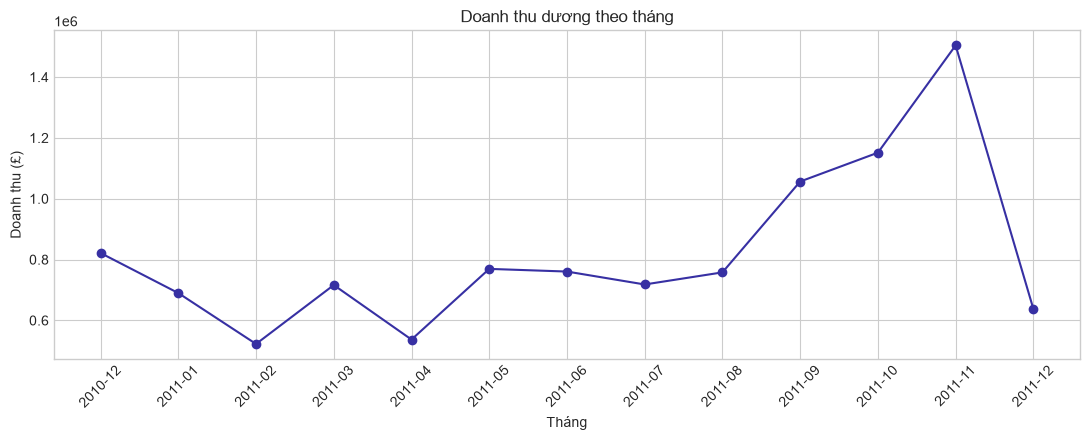

,Month,Revenue,Invoices
0,2010-12,"821,452.730",1559
1,2011-01,"689,811.610",1086
2,2011-02,"522,545.560",1100
3,2011-03,"716,215.260",1454
4,2011-04,"536,968.491",1246
5,2011-05,"769,296.610",1681
6,2011-06,"760,547.010",1533
7,2011-07,"718,076.121",1475
8,2011-08,"757,841.380",1361
9,2011-09,"1,056,435.192",1837


Chú ý: 2011-12 chỉ có dữ liệu đến ngày 09/12.


In [6]:
monthly = (
    sales.assign(Month=sales["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby("Month", as_index=False)
    .agg(Revenue=("Revenue", "sum"), Invoices=("InvoiceNo", "nunique"))
)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly["Month"], monthly["Revenue"], marker="o", color="#3730a3")
ax.set(title="Doanh thu dương theo tháng", xlabel="Tháng", ylabel="Doanh thu (£)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
display(monthly)
print("Chú ý: 2011-12 chỉ có dữ liệu đến ngày 09/12.")


In [7]:
country_revenue = (
    sales.groupby("Country", as_index=False)
    .agg(Revenue=("Revenue", "sum"), Invoices=("InvoiceNo", "nunique"))
    .sort_values("Revenue", ascending=False)
)
uk_share = country_revenue.loc[
    country_revenue["Country"].eq("United Kingdom"), "Revenue"
].iloc[0] / country_revenue["Revenue"].sum()
print("Tỷ trọng doanh thu UK:", f"{uk_share:.2%}")
display(country_revenue.head(10))

non_product_codes = {
    "POST", "DOT", "M", "BANK CHARGES", "AMAZONFEE", "CRUK",
    "D", "S", "PADS", "B", "C2"
}
product_sales = sales.loc[~sales["StockCode"].isin(non_product_codes)]
top_products = (
    product_sales.groupby(["StockCode", "Description"], as_index=False)
    .agg(InvoiceFrequency=("InvoiceNo", "nunique"),
         Quantity=("Quantity", "sum"), Revenue=("Revenue", "sum"))
    .sort_values("InvoiceFrequency", ascending=False)
)
display(top_products.head(10))


Tỷ trọng doanh thu UK: 84.59%


,Country,Revenue,Invoices
36,United Kingdom,"9,001,744.094",18019
24,Netherlands,"285,446.340",94
10,EIRE,"283,140.520",288
14,Germany,"228,678.400",457
13,France,"209,625.370",392
0,Australia,"138,453.810",57
31,Spain,"61,558.560",90
33,Switzerland,"57,067.600",54
3,Belgium,"41,196.340",98
32,Sweden,"38,367.830",36


,StockCode,Description,InvoiceFrequency,Quantity,Revenue
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2189,37580,"104,284.240"
3619,85099B,JUMBO BAG RED RETROSPOT,2089,48371,"94,159.810"
1340,22423,REGENCY CAKESTAND 3 TIER,1988,13851,"174,156.540"
2877,47566,PARTY BUNTING,1685,18283,"99,445.230"
179,20725,LUNCH BAG RED RETROSPOT,1564,19232,"35,572.360"
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,1455,36362,"58,927.620"
1630,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1385,7483,"38,108.890"
448,21212,PACK OF 72 RETROSPOT CAKE CASES,1320,36396,"21,246.450"
182,20727,LUNCH BAG BLACK SKULL.,1273,12195,"22,346.960"
1373,22457,NATURAL SLATE HEART CHALKBOARD,1249,9119,"27,991.610"


## 6. Phân khúc khách hàng bằng RFM + K-Means

- **Recency (R):** số ngày từ lần mua gần nhất đến ngày chốt dữ liệu; càng nhỏ càng tốt.
- **Frequency (F):** số hóa đơn khác nhau; càng lớn càng tốt.
- **Monetary (M):** tổng doanh thu khách hàng; càng lớn càng tốt.

Dữ liệu RFM thường lệch mạnh, vì vậy ta chặn ngoại lệ ở phân vị 99%, dùng `log1p`, rồi chuẩn hóa trước K-Means. Không chuẩn hóa sẽ khiến `Monetary` lấn át hai biến còn lại.


In [8]:
snapshot = customer_sales["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
rfm = (
    customer_sales.groupby("CustomerID")
    .agg(LastPurchase=("InvoiceDate", "max"),
         Frequency=("InvoiceNo", "nunique"),
         Monetary=("Revenue", "sum"))
    .reset_index()
)
rfm["Recency"] = (snapshot - rfm["LastPurchase"].dt.normalize()).dt.days
rfm = rfm.loc[rfm["Monetary"] > 0].copy()

features = rfm[["Recency", "Frequency", "Monetary"]].copy()
for col in features:
    features[col] = features[col].clip(upper=features[col].quantile(0.99))
X = StandardScaler().fit_transform(np.log1p(features))

print("Ngày snapshot:", snapshot.date())
print("Số khách hàng dùng cho RFM:", f"{len(rfm):,}")
display(rfm[["Recency", "Frequency", "Monetary"]].describe())


Ngày snapshot: 2011-12-10
Số khách hàng dùng cho RFM: 4,338


,Recency,Frequency,Monetary
count,"4,338.000","4,338.000","4,338.000"
mean,93.059,4.272,"2,048.688"
std,100.012,7.698,"8,985.230"
min,1.000,1.000,3.750
25%,18.000,1.000,306.482
50%,51.000,2.000,668.570
75%,142.750,5.000,"1,660.597"
max,374.000,209.000,"280,206.020"


,k,Silhouette,Inertia
0,2,0.435,"6,347.082"
1,3,0.337,"4,739.225"
2,4,0.335,"3,796.958"
3,5,0.317,"3,168.461"
4,6,0.314,"2,731.358"


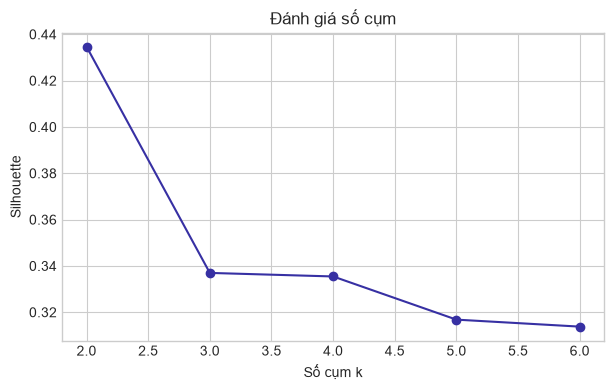

k=2 có Silhouette cao nhất, nhưng chọn k=4 để tạo nhóm kinh doanh chi tiết hơn.


In [9]:
k_results = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X)
    k_results.append({
        "k": k,
        "Silhouette": silhouette_score(X, labels),
        "Inertia": model.inertia_
    })
k_results = pd.DataFrame(k_results)
display(k_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_results["k"], k_results["Silhouette"], marker="o", color="#3730a3")
ax.set(title="Đánh giá số cụm", xlabel="Số cụm k", ylabel="Silhouette")
plt.show()

print("k=2 có Silhouette cao nhất, nhưng chọn k=4 để tạo nhóm kinh doanh chi tiết hơn.")


In [10]:
chosen_k = 4
model = KMeans(n_clusters=chosen_k, n_init=50, random_state=42)
rfm["Cluster"] = model.fit_predict(X)

profile = (
    rfm.groupby("Cluster")
    .agg(Customers=("CustomerID", "count"),
         RecencyMedian=("Recency", "median"),
         FrequencyMedian=("Frequency", "median"),
         MonetaryMedian=("Monetary", "median"),
         MonetaryTotal=("Monetary", "sum"))
    .reset_index()
)
profile["CustomerShare"] = profile["Customers"] / len(rfm)
profile["RevenueShare"] = profile["MonetaryTotal"] / rfm["Monetary"].sum()

# Đặt tên tự động dựa trên hồ sơ cụm để không phụ thuộc số nhãn ngẫu nhiên.
high_value = profile["MonetaryMedian"].idxmax()
dormant = profile["RecencyMedian"].idxmax()
remaining = [i for i in profile.index if i not in {high_value, dormant}]
core = max(remaining, key=lambda i: profile.loc[i, "FrequencyMedian"])
new_low = next(i for i in remaining if i != core)
profile["Segment"] = ""
profile.loc[high_value, "Segment"] = "Giá trị cao"
profile.loc[dormant, "Segment"] = "Ngủ quên"
profile.loc[core, "Segment"] = "Khách cốt lõi"
profile.loc[new_low, "Segment"] = "Mới/ít mua"

label_map = profile.set_index("Cluster")["Segment"].to_dict()
rfm["Segment"] = rfm["Cluster"].map(label_map)
display(profile.sort_values("RevenueShare", ascending=False))

# Kiểm tra độ ổn định qua nhiều random seed bằng ARI.
ari = []
for seed in range(10):
    alt = KMeans(n_clusters=4, n_init=1, random_state=seed).fit_predict(X)
    ari.append(adjusted_rand_score(rfm["Cluster"], alt))
print(f"ARI trung bình qua 10 seed: {np.mean(ari):.3f} ± {np.std(ari):.3f}")


,Cluster,Customers,RecencyMedian,FrequencyMedian,MonetaryMedian,MonetaryTotal,CustomerShare,RevenueShare,Segment
1,1,766,9.000,9.500,"3,552.790","5,862,564.470",0.177,0.660,Giá trị cao
3,3,1201,57.000,4.000,"1,309.140","2,102,273.583",0.277,0.237,Khách cốt lõi
0,0,1488,190.000,1.000,292.735,"502,333.231",0.343,0.057,Ngủ quên
2,2,883,20.000,2.000,408.800,"420,037.610",0.204,0.047,Mới/ít mua


ARI trung bình qua 10 seed: 0.951 ± 0.013


**Hành động gợi ý theo phân khúc**

| Phân khúc | Hướng xử lý |
|---|---|
| Giá trị cao | VIP, ưu tiên chăm sóc và giữ chân |
| Khách cốt lõi | cross-sell, chương trình thành viên |
| Mới/ít mua | ưu đãi cho lần mua thứ hai |
| Ngủ quên | chiến dịch tái kích hoạt có giới hạn chi phí |


# PHẦN BỔ SUNG THEO ĐỀ BÀI

Các mục dưới đây dùng lại hai tập dữ liệu đã tạo ở phần tiền xử lý:

- `sales`: giao dịch bán hợp lệ, doanh thu dương;
- `customer_sales`: tập `sales` có `CustomerID` thật.

Mục tiêu là bổ sung đúng **4, 6, 12 và 13** trong nội dung bài tập, đồng thời giữ nguyên các phần 1–2–3 đã làm.

## Mục 4. Phân tích giỏ hàng – Luật kết hợp bằng Apriori

**Mục tiêu:** tìm các sản phẩm thường xuất hiện cùng nhau và sinh luật kết hợp phục vụ cross-sell/bố trí sản phẩm.

Phân tích dùng các hóa đơn tại **United Kingdom** vì đây là thị trường chiếm phần lớn dữ liệu. Mã dịch vụ/phí được loại khỏi giỏ hàng.

- **Support:** tỷ lệ hóa đơn chứa itemset.
- **Confidence A → B:** trong các hóa đơn chứa A, tỷ lệ cũng chứa B.
- **Lift:** mức đồng xuất hiện so với trường hợp độc lập; `lift > 1` cho thấy liên hệ dương.

Ở đây cài đặt **Apriori tối giản** đến itemset kích thước 3. Ngưỡng dùng để tránh sinh quá nhiều luật trên hơn 16 nghìn giỏ hàng:

- support ≥ 2%;
- confidence ≥ 40%;
- lift ≥ 1.2.

> Luật kết hợp thể hiện đồng xuất hiện, **không chứng minh quan hệ nhân quả**.

In [11]:
import math

# Tạo transaction: mỗi InvoiceNo là một giỏ hàng gồm các StockCode duy nhất.
apriori_sales = sales.loc[
    sales["Country"].eq("United Kingdom")
    & ~sales["StockCode"].isin(non_product_codes)
].copy()

transactions = (
    apriori_sales.groupby("InvoiceNo")["StockCode"]
    .agg(lambda s: frozenset(s.astype(str)))
)
transactions = transactions.loc[transactions.map(len) >= 2].tolist()

N_TRANSACTIONS = len(transactions)
MIN_SUPPORT = 0.02
MIN_CONFIDENCE = 0.40
MIN_LIFT = 1.20
MIN_COUNT = math.ceil(MIN_SUPPORT * N_TRANSACTIONS)

# ---------- Apriori L1 ----------
single_counts = Counter(item for basket in transactions for item in basket)
L1 = {
    frozenset([item]): count
    for item, count in single_counts.items()
    if count >= MIN_COUNT
}
frequent_single_items = {next(iter(itemset)) for itemset in L1}

# ---------- Apriori L2 ----------
pair_counts = Counter()
for basket in transactions:
    filtered = sorted(basket & frequent_single_items)
    pair_counts.update(frozenset(pair) for pair in combinations(filtered, 2))

L2 = {itemset: count for itemset, count in pair_counts.items() if count >= MIN_COUNT}

# ---------- Apriori L3: join + prune ----------
L2_keys = list(L2)
L2_set = set(L2_keys)
candidates_3 = set()
for left, right in combinations(L2_keys, 2):
    candidate = left | right
    if len(candidate) != 3:
        continue
    # Apriori prune: mọi tập con kích thước 2 phải phổ biến.
    if all(
        frozenset(subset) in L2_set
        for subset in combinations(sorted(candidate), 2)
    ):
        candidates_3.add(candidate)

triple_counts = Counter()
for basket in transactions:
    for candidate in candidates_3:
        if candidate.issubset(basket):
            triple_counts[candidate] += 1

L3 = {
    itemset: count
    for itemset, count in triple_counts.items()
    if count >= MIN_COUNT
}

support_counts = {**L1, **L2, **L3}

description_map = (
    apriori_sales.dropna(subset=["Description"])
    .groupby("StockCode")["Description"]
    .agg(lambda s: s.value_counts().index[0])
    .to_dict()
)

def itemset_label(itemset):
    parts = []
    for code in sorted(itemset):
        desc = description_map.get(code, code)
        parts.append(f"{code} – {desc}")
    return " | ".join(parts)

frequent_itemsets_df = pd.DataFrame([
    {
        "Size": len(itemset),
        "Itemset": itemset_label(itemset),
        "Support": count / N_TRANSACTIONS,
        "Invoices": count,
    }
    for itemset, count in support_counts.items()
]).sort_values(["Size", "Support"], ascending=[True, False])

# Sinh association rules từ mọi frequent itemset kích thước >= 2.
rules = []
for itemset, itemset_count in support_counts.items():
    if len(itemset) < 2:
        continue
    items = sorted(itemset)
    for r in range(1, len(items)):
        for antecedent_tuple in combinations(items, r):
            antecedent = frozenset(antecedent_tuple)
            consequent = itemset - antecedent
            ant_count = support_counts.get(antecedent)
            con_count = support_counts.get(consequent)
            if ant_count is None or con_count is None:
                continue
            support = itemset_count / N_TRANSACTIONS
            confidence = itemset_count / ant_count
            consequent_support = con_count / N_TRANSACTIONS
            lift = confidence / consequent_support
            if confidence >= MIN_CONFIDENCE and lift >= MIN_LIFT:
                rules.append({
                    "AntecedentSet": antecedent,
                    "ConsequentSet": consequent,
                    "Antecedent": itemset_label(antecedent),
                    "Consequent": itemset_label(consequent),
                    "Support": support,
                    "Confidence": confidence,
                    "Lift": lift,
                    "Invoices": itemset_count,
                })

rules_df = pd.DataFrame(rules)
if len(rules_df):
    rules_df = rules_df.sort_values(
        ["Lift", "Confidence", "Support"], ascending=False
    ).reset_index(drop=True)

print(f"Số giỏ hàng UK dùng cho Apriori: {N_TRANSACTIONS:,}")
print(f"Ngưỡng support tối thiểu: {MIN_SUPPORT:.0%} = {MIN_COUNT:,} hóa đơn")
print(f"Frequent itemsets: L1={len(L1):,}, L2={len(L2):,}, L3={len(L3):,}")
print(f"Số luật đạt ngưỡng: {len(rules_df):,}")

display(frequent_itemsets_df.query("Size >= 2").head(15))
if len(rules_df):
    rules_display = rules_df[[
        "Antecedent", "Consequent", "Support", "Confidence", "Lift", "Invoices"
    ]].head(15).copy()
    display(rules_display)


Số giỏ hàng UK dùng cho Apriori: 16,506
Ngưỡng support tối thiểu: 2% = 331 hóa đơn
Frequent itemsets: L1=346, L2=135, L3=7
Số luật đạt ngưỡng: 180


,Size,Itemset,Support,Invoices
387,2,22386 – JUMBO BAG PINK POLKADOT | 85099B – JUM...,0.048,785
427,2,22697 – GREEN REGENCY TEACUP AND SAUCER | 2269...,0.042,700
377,2,21931 – JUMBO STORAGE BAG SUKI | 85099B – JUMB...,0.042,698
393,2,22411 – JUMBO SHOPPER VINTAGE RED PAISLEY | 85...,0.040,657
379,2,20725 – LUNCH BAG RED RETROSPOT | 20727 – LUNC...,0.037,607
381,2,20725 – LUNCH BAG RED RETROSPOT | 22383 – LUNC...,0.036,602
448,2,22697 – GREEN REGENCY TEACUP AND SAUCER | 2269...,0.035,576
357,2,85099B – JUMBO BAG RED RETROSPOT | 85099C – JU...,0.035,570
373,2,20727 – LUNCH BAG BLACK SKULL. | 22383 – LUNC...,0.034,565
361,2,22726 – ALARM CLOCK BAKELIKE GREEN | 22727 – A...,0.034,563


,Antecedent,Consequent,Support,Confidence,Lift,Invoices
0,84596B – SMALL DOLLY MIX DESIGN ORANGE BOWL,84596F – SMALL MARSHMALLOWS PINK BOWL,0.020,0.663,26.195,335
1,84596F – SMALL MARSHMALLOWS PINK BOWL,84596B – SMALL DOLLY MIX DESIGN ORANGE BOWL,0.020,0.801,26.195,335
2,22578 – WOODEN STAR CHRISTMAS SCANDINAVIAN,22577 – WOODEN HEART CHRISTMAS SCANDINAVIAN,0.022,0.770,24.966,368
3,22577 – WOODEN HEART CHRISTMAS SCANDINAVIAN,22578 – WOODEN STAR CHRISTMAS SCANDINAVIAN,0.022,0.723,24.966,368
4,22698 – PINK REGENCY TEACUP AND SAUCER,22697 – GREEN REGENCY TEACUP AND SAUCER | 2269...,0.030,0.705,16.621,492
5,22697 – GREEN REGENCY TEACUP AND SAUCER | 2269...,22698 – PINK REGENCY TEACUP AND SAUCER,0.030,0.703,16.621,492
6,22866 – HAND WARMER SCOTTY DOG DESIGN,22865 – HAND WARMER OWL DESIGN,0.020,0.619,16.261,331
7,22865 – HAND WARMER OWL DESIGN,22866 – HAND WARMER SCOTTY DOG DESIGN,0.020,0.527,16.261,331
8,22698 – PINK REGENCY TEACUP AND SAUCER | 22699...,22697 – GREEN REGENCY TEACUP AND SAUCER,0.030,0.903,15.988,492
9,22697 – GREEN REGENCY TEACUP AND SAUCER,22698 – PINK REGENCY TEACUP AND SAUCER | 22699...,0.030,0.528,15.988,492


### Trực quan hóa mạng luật kết hợp

Biểu đồ dưới chỉ dùng các luật **1 sản phẩm → 1 sản phẩm** mạnh nhất để mạng dễ đọc. Mỗi mũi tên biểu diễn hướng của luật; nhãn cạnh hiển thị `lift`.

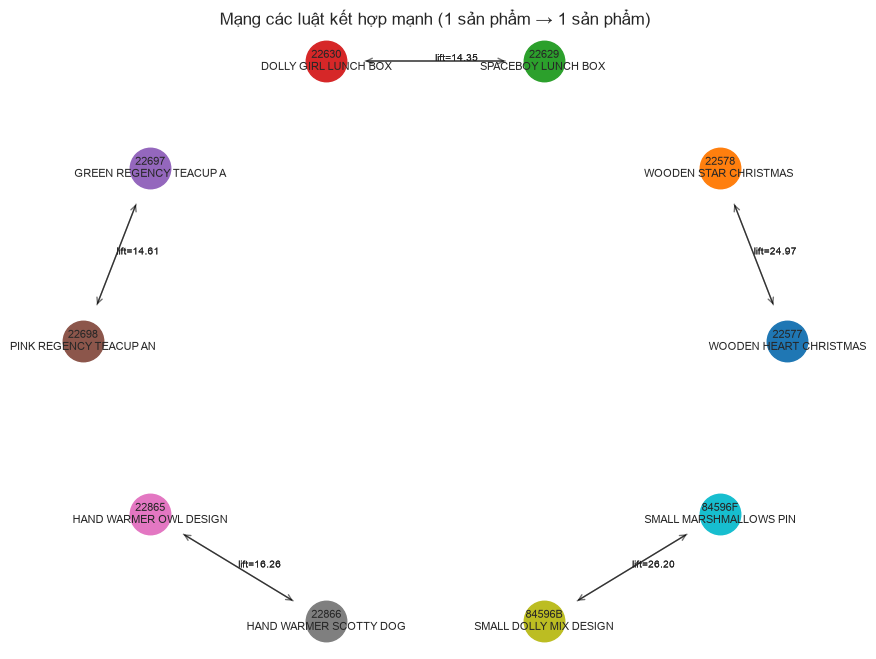

In [12]:
# Chọn tối đa 10 luật 1 -> 1 có lift cao để vẽ mạng.
pair_rules = rules_df.loc[
    rules_df["AntecedentSet"].map(len).eq(1)
    & rules_df["ConsequentSet"].map(len).eq(1)
].head(10).copy()

if pair_rules.empty:
    print("Không có luật 1→1 đạt ngưỡng để vẽ mạng.")
else:
    def one_code(itemset):
        return next(iter(itemset))

    edge_rows = []
    for _, row in pair_rules.iterrows():
        a = one_code(row["AntecedentSet"])
        b = one_code(row["ConsequentSet"])
        edge_rows.append((a, b, row["Lift"]))

    nodes = sorted(set([a for a, _, _ in edge_rows] + [b for _, b, _ in edge_rows]))
    angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
    positions = {
        node: (np.cos(angle), np.sin(angle))
        for node, angle in zip(nodes, angles)
    }

    fig, ax = plt.subplots(figsize=(10, 8))
    for node, (x, y) in positions.items():
        ax.scatter(x, y, s=850)
        desc = description_map.get(node, node)
        label = f"{node}\n{desc[:22]}"
        ax.text(x, y, label, ha="center", va="center", fontsize=8)

    for a, b, lift in edge_rows:
        x1, y1 = positions[a]
        x2, y2 = positions[b]
        ax.annotate(
            "",
            xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", shrinkA=28, shrinkB=28, alpha=0.55)
        )
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my, f"lift={lift:.2f}", fontsize=7)

    ax.set_title("Mạng các luật kết hợp mạnh (1 sản phẩm → 1 sản phẩm)")
    ax.axis("off")
    plt.show()


## Mục 6. Hệ thống gợi ý sản phẩm – Item-item collaborative filtering

**Mục tiêu:** gợi ý sản phẩm dựa trên lịch sử mua của khách hàng.

Thiết kế đánh giá:

1. Chỉ dùng khách có ít nhất 2 hóa đơn.
2. **Hóa đơn cuối cùng của mỗi khách** được giữ lại làm test set (leave-last-invoice-out).
3. Phần lịch sử trước đó là train set.
4. Xây ma trận user–item nhị phân trên 800 sản phẩm phổ biến nhất trong train.
5. Tính **cosine similarity giữa các sản phẩm**.
6. Với mỗi khách, cộng điểm tương đồng từ các sản phẩm đã mua và loại các item đã thấy.
7. Đánh giá bằng `Precision@10` và `Recall@10`, đồng thời so với baseline **Top-popular**.

Việc chỉ đánh giá trên candidate set 800 sản phẩm giúp notebook chạy ổn trên máy cá nhân và làm phép so sánh công bằng giữa hai mô hình.

In [13]:
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

reco_sales = customer_sales.loc[
    ~customer_sales["StockCode"].isin(non_product_codes)
].copy()

# Xác định thứ tự hóa đơn của từng khách.
invoice_order = (
    reco_sales.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(InvoiceDate=("InvoiceDate", "max"))
    .sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
)

invoice_counts = invoice_order.groupby("CustomerID")["InvoiceNo"].size()
eligible_customers = invoice_counts.loc[invoice_counts >= 2].index
invoice_order = invoice_order.loc[
    invoice_order["CustomerID"].isin(eligible_customers)
].copy()

last_invoice = (
    invoice_order.groupby("CustomerID").tail(1)[["CustomerID", "InvoiceNo"]]
    .assign(_is_test=1)
)

reco_work = reco_sales.loc[
    reco_sales["CustomerID"].isin(eligible_customers)
].merge(last_invoice, on=["CustomerID", "InvoiceNo"], how="left")

train_reco = reco_work.loc[reco_work["_is_test"].isna()].copy()
test_reco = reco_work.loc[reco_work["_is_test"].eq(1)].copy()

# Candidate set: 800 sản phẩm có nhiều khách mua nhất trong train.
item_popularity = (
    train_reco.groupby("StockCode")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
)
candidate_items = item_popularity.head(800).index.tolist()

users = sorted(map(int, eligible_customers))
user_to_idx = {uid: i for i, uid in enumerate(users)}
item_to_idx = {item: i for i, item in enumerate(candidate_items)}
idx_to_item = {i: item for item, i in item_to_idx.items()}

train_ui = (
    train_reco.loc[train_reco["StockCode"].isin(candidate_items), ["CustomerID", "StockCode"]]
    .drop_duplicates()
)

rows = train_ui["CustomerID"].map(user_to_idx).astype(int).to_numpy()
cols = train_ui["StockCode"].map(item_to_idx).astype(int).to_numpy()
values = np.ones(len(train_ui), dtype=np.float32)

user_item = csr_matrix(
    (values, (rows, cols)),
    shape=(len(users), len(candidate_items))
)

item_similarity = cosine_similarity(user_item.T, dense_output=True)
np.fill_diagonal(item_similarity, 0.0)

popular_item_indices = [item_to_idx[item] for item in candidate_items]

def recommend_item_item(customer_id, k=10):
    """Trả về index item; nếu thiếu điểm similarity thì fill bằng popularity."""
    row_idx = user_to_idx[int(customer_id)]
    seen = set(user_item.getrow(row_idx).indices.tolist())

    if seen:
        scores = item_similarity[:, list(seen)].sum(axis=1)
    else:
        scores = np.zeros(len(candidate_items), dtype=float)
    scores = np.asarray(scores).ravel()
    if seen:
        scores[list(seen)] = -np.inf

    positive = np.where(scores > 0)[0]
    ranked = positive[np.argsort(-scores[positive])].tolist()

    # Fill bằng phổ biến để luôn có tối đa k gợi ý hợp lệ.
    selected = []
    selected_set = set()
    for idx in ranked + popular_item_indices:
        if idx in seen or idx in selected_set:
            continue
        selected.append(idx)
        selected_set.add(idx)
        if len(selected) >= k:
            break
    return selected

def recommend_popular(customer_id, k=10):
    row_idx = user_to_idx[int(customer_id)]
    seen = set(user_item.getrow(row_idx).indices.tolist())
    return [idx for idx in popular_item_indices if idx not in seen][:k]

# Ground truth: sản phẩm trong hóa đơn cuối, chỉ xét candidate set.
test_sets = (
    test_reco.loc[test_reco["StockCode"].isin(candidate_items)]
    .groupby("CustomerID")["StockCode"]
    .agg(lambda s: set(s))
)

K = 10
model_metrics = []
baseline_metrics = []
for customer_id, relevant_codes in test_sets.items():
    relevant = {item_to_idx[item] for item in relevant_codes}
    if not relevant:
        continue

    model_rec = recommend_item_item(customer_id, K)
    model_hits = len(set(model_rec) & relevant)
    model_metrics.append((model_hits / K, model_hits / len(relevant)))

    base_rec = recommend_popular(customer_id, K)
    base_hits = len(set(base_rec) & relevant)
    baseline_metrics.append((base_hits / K, base_hits / len(relevant)))

model_precision, model_recall = np.mean(model_metrics, axis=0)
base_precision, base_recall = np.mean(baseline_metrics, axis=0)

evaluation_df = pd.DataFrame({
    "Model": ["Item-item cosine", "Top-popular baseline"],
    "Precision@10": [model_precision, base_precision],
    "Recall@10": [model_recall, base_recall],
    "EvaluatedCustomers": [len(model_metrics), len(baseline_metrics)],
})

display(evaluation_df)
print(f"Số khách đủ điều kiện train/test: {len(users):,}")
print(f"Số khách có item test nằm trong candidate set: {len(model_metrics):,}")


,Model,Precision@10,Recall@10,EvaluatedCustomers
0,Item-item cosine,0.049,0.040,2703
1,Top-popular baseline,0.026,0.021,2703


Số khách đủ điều kiện train/test: 2,829
Số khách có item test nằm trong candidate set: 2,703


### Ví dụ top-10 sản phẩm gợi ý

Chọn 3 khách hàng có doanh thu train cao trong số khách được đánh giá để minh họa. Kết quả này chỉ là **gợi ý từ hành vi mua**, không phải dự đoán chắc chắn khách sẽ mua.

In [14]:
train_value = (
    train_reco.groupby("CustomerID")["Revenue"].sum()
    .sort_values(ascending=False)
)
example_customers = [
    int(uid) for uid in train_value.index
    if uid in test_sets.index
][:3]

recommendation_rows = []
for customer_id in example_customers:
    rec_indices = recommend_item_item(customer_id, 10)
    for rank, idx in enumerate(rec_indices, start=1):
        code = idx_to_item[idx]
        recommendation_rows.append({
            "CustomerID": customer_id,
            "Rank": rank,
            "StockCode": code,
            "Description": description_map.get(code, ""),
        })

recommendations_sample_df = pd.DataFrame(recommendation_rows)
display(recommendations_sample_df)


,CustomerID,Rank,StockCode,Description
0,14646,1,23208,LUNCH BAG VINTAGE LEAF DESIGN
1,14646,2,23202,JUMBO BAG VINTAGE LEAF
2,14646,3,23308,SET OF 60 VINTAGE LEAF CAKE CASES
3,14646,4,22722,SET OF 6 SPICE TINS PANTRY DESIGN
4,14646,5,22139,RETROSPOT TEA SET CERAMIC 11 PC
5,14646,6,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS
6,14646,7,22197,POPCORN HOLDER
7,14646,8,23300,GARDENERS KNEELING PAD CUP OF TEA
8,14646,9,23301,GARDENERS KNEELING PAD KEEP CALM
9,14646,10,21915,RED HARMONICA IN BOX


## Mục 12. Chu kỳ sản phẩm & biến động phổ biến

**Mục tiêu:** phát hiện SKU đang tăng/giảm và xác định thời điểm bán đạt đỉnh.

Cách làm:

- Gom `Quantity` theo **tuần kết thúc Chủ nhật**.
- Vì dữ liệu kết thúc ngày 09/12/2011 nên tuần cuối chưa đầy đủ; loại tuần này khỏi phép so sánh.
- So sánh **8 tuần gần nhất đầy đủ** với **8 tuần ngay trước đó**.
- Chỉ xếp hạng SKU có đủ nền dữ liệu (`PrevQty >= 200`, hoạt động ít nhất 4 tuần ở cả hai giai đoạn) để hạn chế các tỷ lệ tăng trưởng ảo do mẫu quá nhỏ.
- `GrowthPct = (RecentAvgWeek - PrevAvgWeek) / PrevAvgWeek × 100`.
- Đồng thời tìm tháng có tổng lượng bán cao nhất của từng SKU (`PeakMonth`).

In [15]:
trend_sales = sales.loc[
    ~sales["StockCode"].isin(non_product_codes)
].copy()

trend_sales["WeekEnd"] = (
    trend_sales["InvoiceDate"].dt.to_period("W-SUN").dt.end_time.dt.normalize()
)
max_date = trend_sales["InvoiceDate"].max().normalize()
last_complete_week = (max_date.to_period("W-SUN") - 1).end_time.normalize()

recent_start = last_complete_week - pd.Timedelta(weeks=7)
previous_end = recent_start - pd.Timedelta(weeks=1)
previous_start = previous_end - pd.Timedelta(weeks=7)

weekly_qty = (
    trend_sales.loc[trend_sales["WeekEnd"] <= last_complete_week]
    .groupby(["StockCode", "WeekEnd"], as_index=False)
    .agg(Quantity=("Quantity", "sum"))
)

previous = (
    weekly_qty.loc[weekly_qty["WeekEnd"].between(previous_start, previous_end)]
    .groupby("StockCode")["Quantity"]
    .agg(PrevQty="sum", PrevWeeks="size")
)
recent = (
    weekly_qty.loc[weekly_qty["WeekEnd"].between(recent_start, last_complete_week)]
    .groupby("StockCode")["Quantity"]
    .agg(RecentQty="sum", RecentWeeks="size")
)

trend_table = previous.join(recent, how="outer").fillna(0)
trend_table["PrevAvgWeek"] = trend_table["PrevQty"] / 8
trend_table["RecentAvgWeek"] = trend_table["RecentQty"] / 8
trend_table["AbsChange"] = trend_table["RecentQty"] - trend_table["PrevQty"]
trend_table["GrowthPct"] = (
    (trend_table["RecentAvgWeek"] - trend_table["PrevAvgWeek"])
    / trend_table["PrevAvgWeek"] * 100
)

# Tháng đạt đỉnh lượng bán của từng SKU.
monthly_qty = (
    trend_sales.assign(Month=trend_sales["InvoiceDate"].dt.to_period("M").astype(str))
    .groupby(["StockCode", "Month"], as_index=False)
    .agg(Quantity=("Quantity", "sum"))
)
peak_month = (
    monthly_qty.sort_values(["StockCode", "Quantity"], ascending=[True, False])
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Month"]
)

# Dùng mô tả gần nhất của mỗi SKU; nhanh hơn tính mode trên toàn bộ 500k+ dòng.
trend_description_map = (
    trend_sales.sort_values("InvoiceDate")
    .drop_duplicates("StockCode", keep="last")
    .set_index("StockCode")["Description"]
    .to_dict()
)

stable_trend = trend_table.loc[
    (trend_table["PrevQty"] >= 200)
    & (trend_table["PrevWeeks"] >= 4)
    & (trend_table["RecentWeeks"] >= 4)
].copy()
stable_trend["Description"] = stable_trend.index.map(trend_description_map)
stable_trend["PeakMonth"] = stable_trend.index.map(peak_month)

# Thêm điều kiện thay đổi tuyệt đối để tránh top-list chỉ do phần trăm trên nền nhỏ.
rising = (
    stable_trend.loc[stable_trend["AbsChange"] >= 200]
    .sort_values(["GrowthPct", "AbsChange"], ascending=False)
    .head(10)
)
falling = (
    stable_trend.loc[stable_trend["AbsChange"] <= -200]
    .sort_values(["GrowthPct", "AbsChange"], ascending=True)
    .head(10)
)

print("Khoảng trước:", previous_start.date(), "→", previous_end.date())
print("Khoảng gần nhất:", recent_start.date(), "→", last_complete_week.date())
print("Tuần chưa đầy đủ đã loại:", (last_complete_week + pd.Timedelta(weeks=1)).date())

print("\nTop 10 SKU tăng trưởng nhanh:")
display(rising[[
    "Description", "PrevQty", "RecentQty", "AbsChange", "GrowthPct", "PeakMonth"
]])

print("Top 10 SKU suy giảm mạnh:")
display(falling[[
    "Description", "PrevQty", "RecentQty", "AbsChange", "GrowthPct", "PeakMonth"
]])


Khoảng trước: 2011-08-21 → 2011-10-09
Khoảng gần nhất: 2011-10-16 → 2011-12-04
Tuần chưa đầy đủ đã loại: 2011-12-11

Top 10 SKU tăng trưởng nhanh:


,Description,PrevQty,RecentQty,AbsChange,GrowthPct,PeakMonth
StockCode,,,,,,
23084,RABBIT NIGHT LIGHT,"2,419.000","21,964.000","19,545.000",807.979,2011-11
20668,DISCO BALL CHRISTMAS DECORATION,831.000,"7,233.000","6,402.000",770.397,2011-11
20973,12 PENCIL SMALL TUBE WOODLAND,295.000,"2,130.000","1,835.000",622.034,2011-11
21819,GLITTER CHRISTMAS STAR,270.000,"1,949.000","1,679.000",621.852,2011-11
21810,CHRISTMAS HANGING STAR WITH BELL,780.000,"4,488.000","3,708.000",475.385,2011-11
35953,FOLKART STAR CHRISTMAS DECORATIONS,482.000,"2,733.000","2,251.000",467.012,2011-11
22338,STAR DECORATION PAINTED ZINC,630.000,"3,524.000","2,894.000",459.365,2011-11
22597,MUSICAL ZINC HEART DECORATION,369.000,"1,991.000","1,622.000",439.566,2011-11
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"1,064.000","5,246.000","4,182.000",393.045,2011-11


Top 10 SKU suy giảm mạnh:


,Description,PrevQty,RecentQty,AbsChange,GrowthPct,PeakMonth
StockCode,,,,,,
21830,ASSORTED CREEPY CRAWLIES,409.000,6.000,-403.000,-98.533,2010-12
22688,DOORMAT PEACE ON EARTH BLUE,650.000,15.000,-635.000,-97.692,2011-09
22117,METAL SIGN HER DINNER IS SERVED,"1,033.000",29.000,"-1,004.000",-97.193,2011-09
22687,DOORMAT CHRISTMAS VILLAGE,553.000,22.000,-531.000,-96.022,2011-09
48116,DOORMAT MULTICOLOUR STRIPE,489.000,23.000,-466.000,-95.297,2011-09
23028,DRAWER KNOB CRACKLE GLAZE BLUE,524.000,29.000,-495.000,-94.466,2011-09
23285,PINK VINTAGE SPOT BEAKER,"2,874.000",163.000,"-2,711.000",-94.328,2011-09
21394,RED POLKADOT BEAKER,844.000,49.000,-795.000,-94.194,2011-06
21873,IF YOU CAN'T STAND THE HEAT MUG,694.000,49.000,-645.000,-92.939,2011-09


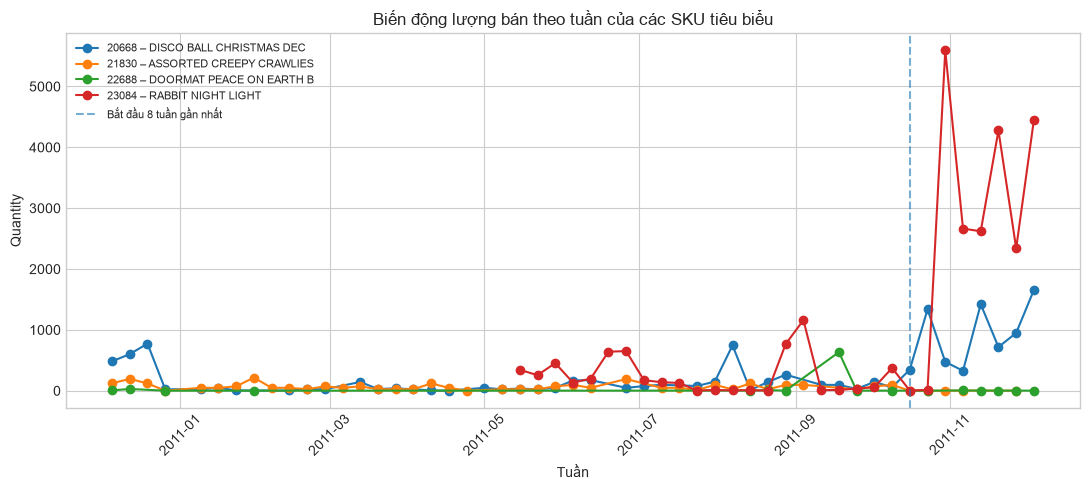

In [16]:
# Vẽ chuỗi tuần cho 2 SKU tăng và 2 SKU giảm để kiểm tra trực quan.
selected_trend_items = list(rising.head(2).index) + list(falling.head(2).index)
plot_weekly = weekly_qty.loc[
    weekly_qty["StockCode"].isin(selected_trend_items)
].copy()

fig, ax = plt.subplots(figsize=(11, 5))
for code, group in plot_weekly.groupby("StockCode"):
    group = group.sort_values("WeekEnd")
    label = f"{code} – {trend_description_map.get(code, '')[:24]}"
    ax.plot(group["WeekEnd"], group["Quantity"], marker="o", label=label)

ax.axvline(recent_start, linestyle="--", alpha=0.6, label="Bắt đầu 8 tuần gần nhất")
ax.set(
    title="Biến động lượng bán theo tuần của các SKU tiêu biểu",
    xlabel="Tuần",
    ylabel="Quantity"
)
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Mục 13. Khai phá chuỗi / phiên giao dịch – PrefixSpan-style

**Mục tiêu:** tìm mẫu mua theo **thứ tự thời gian**, ví dụ sản phẩm A thường xuất hiện ở một lần mua trước rồi sản phẩm B xuất hiện ở lần mua sau.

Điểm quan trọng của dữ liệu Online Retail: các dòng trong cùng một `InvoiceNo` chỉ là các mặt hàng của **cùng một hóa đơn**, không có bằng chứng rằng thứ tự dòng phản ánh thứ tự khách chọn sản phẩm. Vì vậy:

- mỗi `InvoiceNo` được coi là **một session**;
- các session của từng `CustomerID` được sắp theo `InvoiceDate`;
- chỉ xét 40 sản phẩm có nhiều khách mua nhất để giới hạn không gian tìm kiếm;
- cài đặt projected database theo ý tưởng **PrefixSpan**, khai phá chuỗi dài tối đa 3;
- support được tính theo **số khách hàng chứa chuỗi**, không phải số dòng giao dịch;
- ngưỡng support = 3% số khách đủ điều kiện.

Mẫu `A → B` nghĩa là khách từng mua A trong một hóa đơn và sau đó mua B trong **một hóa đơn muộn hơn**. Đây là tín hiệu hành vi tuần tự, không chứng minh A gây ra B.

In [17]:
seq_sales = customer_sales.loc[
    ~customer_sales["StockCode"].isin(non_product_codes)
].copy()

# Chỉ dùng 40 sản phẩm có nhiều khách mua nhất để PrefixSpan chạy nhanh và mẫu dễ diễn giải.
top_seq_items = (
    seq_sales.groupby("StockCode")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
    .head(40)
    .index
    .tolist()
)
seq_filtered = seq_sales.loc[seq_sales["StockCode"].isin(top_seq_items)].copy()

# Mỗi InvoiceNo là một session/itemset.
session_table = (
    seq_filtered.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        InvoiceDate=("InvoiceDate", "min"),
        Items=("StockCode", lambda s: frozenset(set(s)))
    )
    .sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
)

sequence_db = {
    int(customer_id): list(group["Items"])
    for customer_id, group in session_table.groupby("CustomerID")
    if len(group) >= 2
}

SEQ_MIN_SUPPORT = 0.03
SEQ_MAX_LEN = 3
SEQ_MIN_COUNT = math.ceil(SEQ_MIN_SUPPORT * len(sequence_db))

# projected_db: customer_id -> (danh sách session, vị trí bắt đầu tìm tiếp)
def project_database(projected_db, item):
    new_projected = {}
    for customer_id, (sequence, start_pos) in projected_db.items():
        for pos in range(start_pos, len(sequence)):
            if item in sequence[pos]:
                # Item tiếp theo bắt buộc nằm ở session MUỘN HƠN.
                new_projected[customer_id] = (sequence, pos + 1)
                break
    return new_projected

patterns = []

def prefixspan_mine(prefix, projected_db, max_len=3):
    # Mỗi candidate chỉ được đếm 1 lần trên mỗi khách ở mỗi bước mở rộng.
    candidate_support = Counter()
    for _, (sequence, start_pos) in projected_db.items():
        seen_items = set()
        for session_items in sequence[start_pos:]:
            seen_items.update(session_items)
        candidate_support.update(seen_items)

    for item, support_count in candidate_support.items():
        if support_count < SEQ_MIN_COUNT:
            continue
        new_prefix = prefix + (item,)
        new_projected = project_database(projected_db, item)
        actual_support = len(new_projected)
        patterns.append((new_prefix, actual_support))
        if len(new_prefix) < max_len:
            prefixspan_mine(new_prefix, new_projected, max_len)

initial_projection = {
    customer_id: (sequence, 0)
    for customer_id, sequence in sequence_db.items()
}
prefixspan_mine(tuple(), initial_projection, SEQ_MAX_LEN)

pattern_support = {pattern: support for pattern, support in patterns}
seq_rows = []
for pattern, support_count in patterns:
    if len(pattern) < 2:
        continue
    prefix = pattern[:-1]
    prefix_support = pattern_support.get(prefix, len(sequence_db))
    confidence = support_count / prefix_support if prefix_support else np.nan
    seq_rows.append({
        "PatternTuple": pattern,
        "Length": len(pattern),
        "Pattern": " → ".join(
            f"{code} – {trend_description_map.get(code, description_map.get(code, ''))}"
            for code in pattern
        ),
        "Customers": support_count,
        "Support": support_count / len(sequence_db),
        "SequentialConfidence": confidence,
        "DistinctProducts": len(set(pattern)),
    })

sequential_patterns_df = pd.DataFrame(seq_rows)
if len(sequential_patterns_df):
    sequential_patterns_df = sequential_patterns_df.sort_values(
        ["Length", "Support", "SequentialConfidence"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

# Ưu tiên hiển thị chuỗi có ít nhất 2 sản phẩm khác nhau để tránh bảng chỉ toàn mua lặp lại cùng SKU.
sequential_display = (
    sequential_patterns_df.loc[sequential_patterns_df["DistinctProducts"] >= 2]
    .sort_values(["Support", "SequentialConfidence"], ascending=False)
    .head(20)
)

print(f"Số khách có >=2 session trong tập 40 item: {len(sequence_db):,}")
print(f"Ngưỡng support PrefixSpan: {SEQ_MIN_SUPPORT:.0%} = {SEQ_MIN_COUNT:,} khách")
print(f"Tổng số pattern dài 2–3 đạt ngưỡng: {len(sequential_patterns_df):,}")
display(sequential_display[[
    "Length", "Pattern", "Customers", "Support", "SequentialConfidence"
]])


Số khách có >=2 session trong tập 40 item: 2,212
Ngưỡng support PrefixSpan: 3% = 67 khách
Tổng số pattern dài 2–3 đạt ngưỡng: 1,651


,Length,Pattern,Customers,Support,SequentialConfidence
818,2,85099B – JUMBO BAG RED RETROSPOT → 23203 – JUM...,236,0.107,0.446
823,2,20725 – LUNCH BAG RED RETROSPOT → 23209 – LUNC...,213,0.096,0.447
824,2,20725 – LUNCH BAG RED RETROSPOT → 20727 – LUNC...,212,0.096,0.445
826,2,20728 – LUNCH BAG CARS BLUE → 20725 – LUNCH BA...,209,0.094,0.502
827,2,20727 – LUNCH BAG BLACK SKULL. → 20725 – LUNC...,208,0.094,0.506
828,2,20725 – LUNCH BAG RED RETROSPOT → 22382 – LUNC...,207,0.094,0.435
830,2,20725 – LUNCH BAG RED RETROSPOT → 22383 – LUNC...,206,0.093,0.433
831,2,22423 – REGENCY CAKESTAND 3 TIER → 23245 – SET...,206,0.093,0.299
833,2,23203 – JUMBO BAG VINTAGE DOILY → 85099B – JU...,204,0.092,0.463
834,2,22384 – LUNCH BAG PINK POLKADOT → 20725 – LUNC...,201,0.091,0.500


### Use-case của chuỗi mua hàng

- **Next-best-offer:** nếu khách đã mua A ở lần trước, ưu tiên B nếu `A → B` có support và sequential confidence cao.
- **Email/remarketing theo vòng đời:** kích hoạt chiến dịch sau một lần mua thay vì chỉ dựa trên sản phẩm đồng xuất hiện trong cùng hóa đơn.
- **Bổ sung cho Apriori:** Apriori trả lời “A và B thường đi cùng nhau?”, còn sequential pattern trả lời “A thường xuất hiện trước B ở các lần mua khác nhau?”.
- **Phát hiện mua lặp lại:** các mẫu `A → A` có thể đại diện cho sản phẩm tiêu hao hoặc nhu cầu tái mua.

## Kết luận phần bổ sung 4–6–12–13

1. **Apriori:** tìm frequent itemset kích thước 1–3, sinh luật bằng support/confidence/lift và trực quan hóa mạng luật mạnh.
2. **Recommender:** item-item cosine dùng lịch sử mua, đánh giá leave-last-invoice-out bằng Precision@10/Recall@10 và so với Top-popular baseline.
3. **Product trend:** so sánh hai cửa sổ 8 tuần, loại tuần cuối chưa đầy đủ và lọc SKU có đủ volume để giảm nhiễu.
4. **Sequential mining:** coi mỗi invoice là một session, sau đó dùng projected database kiểu PrefixSpan để tìm chuỗi mua giữa các lần mua khác nhau.

### Giới hạn cần nêu trong báo cáo

- Association rule và sequential pattern là quan hệ thống kê, không chứng minh nhân quả.
- Recommender chỉ dùng implicit feedback “đã mua/chưa mua”; không có rating hay thông tin sở thích trực tiếp.
- Candidate set 800 item và top-40 item cho PrefixSpan là lựa chọn thực dụng để notebook chạy ổn, nên không bao phủ toàn bộ long-tail.
- Dữ liệu chỉ kéo dài khoảng một năm; kết luận seasonality dài hạn còn hạn chế.
- Tháng 12/2011 và tuần cuối là dữ liệu chưa đầy đủ, nên không được diễn giải như một giai đoạn kinh doanh hoàn chỉnh.

In [18]:
# Tóm tắt và xuất các bảng kết quả chính ra CSV.
OUTPUT_DIR = Path("online_retail_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

rules_export = rules_df.drop(columns=["AntecedentSet", "ConsequentSet"], errors="ignore")
rules_export.to_csv(OUTPUT_DIR / "muc4_apriori_rules.csv", index=False, encoding="utf-8-sig")
evaluation_df.to_csv(OUTPUT_DIR / "muc6_recommender_evaluation.csv", index=False, encoding="utf-8-sig")
recommendations_sample_df.to_csv(OUTPUT_DIR / "muc6_recommendations_sample.csv", index=False, encoding="utf-8-sig")

trend_export = stable_trend.reset_index().rename(columns={"index": "StockCode"})
trend_export.to_csv(OUTPUT_DIR / "muc12_product_trends.csv", index=False, encoding="utf-8-sig")

sequential_export = sequential_patterns_df.drop(columns=["PatternTuple"], errors="ignore")
sequential_export.to_csv(OUTPUT_DIR / "muc13_sequential_patterns.csv", index=False, encoding="utf-8-sig")

final_summary = pd.Series({
    "Dòng thô": len(df),
    "Dòng bán hợp lệ": len(sales),
    "Khách hàng RFM": len(rfm),
    "Giỏ hàng dùng cho Apriori": N_TRANSACTIONS,
    "Frequent itemsets size 2–3": len(L2) + len(L3),
    "Luật Apriori đạt ngưỡng": len(rules_df),
    "Khách đánh giá recommender": len(model_metrics),
    "Recommender Precision@10": model_precision,
    "Recommender Recall@10": model_recall,
    "SKU đủ điều kiện trend": len(stable_trend),
    "Sequential patterns dài 2–3": len(sequential_patterns_df),
}, name="Kết quả")

display(final_summary.to_frame())
print("Đã xuất CSV vào:", OUTPUT_DIR.resolve())


,Kết quả
Dòng thô,"541,909.000"
Dòng bán hợp lệ,"524,878.000"
Khách hàng RFM,"4,338.000"
Giỏ hàng dùng cho Apriori,"16,506.000"
Frequent itemsets size 2–3,142.000
Luật Apriori đạt ngưỡng,180.000
Khách đánh giá recommender,"2,703.000"
Recommender Precision@10,0.049
Recommender Recall@10,0.040
SKU đủ điều kiện trend,989.000


Đã xuất CSV vào: D:\Study\Khaiphadulieu\Online Retail v2\online_retail_outputs
